# Additional Landmark related Metric Evaluation

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")
from src.metrics.handcrafted_metrics import compute_extended_hand_metrics, analyze_metrics_vs_grs, compute_rotational_metrics, compute_bimanual_dexterity

In [187]:
from scipy.stats import pearsonr

def leakage_free_correlation_analysis(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    n = 5
):
    """
    Evaluates candidate features by identifying their contribution to residuals
    using a Leave-One-Surgeon-Out cross-validation approach.
    """
    unique_surgeons = df[surgeon_col].unique()
    fold_results = []

    for surgeon_out in tqdm(unique_surgeons, desc="Analyzing Folds"):
        # Split Data
        df_train = df[df[surgeon_col] != surgeon_out].dropna(subset=[target] + candidate_features).copy()
        
        # Correlation between candidate features and target
        for feat in candidate_features:
            r, _ = pearsonr(df_train[feat], df_train[target])
            fold_results.append({
                'Fold_Surgeon_Out': surgeon_out,
                'Feature': feat,
                'Corr_with_Target': r
            })

    # ==============================
    # 4. Aggregate Results across all folds
    # ==============================
    results_df = pd.DataFrame(fold_results)
    
    # We want to know:
    # 1. Mean Partial R2
    # 2. Selection Frequency (how often is it in the top 10?)
    summary = results_df.groupby('Feature').agg({
        'Corr_with_Target': ['mean', 'std', 'min', 'max']
    }).reset_index()
    
    summary.columns = ['Feature', 'Mean_Corr_with_Target', 'Std_Corr_with_Target', 'Min_Corr_with_Target', 'Max_Corr_with_Target']

    results_df['Corr_with_Target'] = results_df['Corr_with_Target'].abs()
    
    # Calculate "Stability": How often was this feature in the top 10 of its fold?
    results_df['Rank'] = results_df.groupby('Fold_Surgeon_Out')['Corr_with_Target'].rank(ascending=False)
    stability = results_df[results_df['Rank'] <= n]['Feature'].value_counts() / len(unique_surgeons)
    stability = stability.rename('Selection_Stability').reset_index().rename(columns={'index': 'Feature'})
    
    final_summary = summary.merge(stability, on='Feature', how='left').fillna(0)
    
    return final_summary.sort_values(by='Mean_Corr_with_Target', key=abs, ascending=False)


In [34]:
df_metrics, correlations = analyze_metrics_vs_grs(
    processed_dir="data/processed/landmark_dataframes/",
    ratings_csv="data/scores/merged_scores.csv",
    metric_func=compute_rotational_metrics,
    fps=30,
    correlation="spearman",
    end = "30fps_processed.pkl"
)

100%|██████████| 86/86 [00:45<00:00,  1.88it/s]


In [35]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_correlations(correlations_dict, title="Correlation with GRS_Total"):
    """
    Plot correlations as a bar chart with correlation values on top.
    
    Parameters
    ----------
    correlations_dict : dict
        Dictionary of correlations, format: {metric_name: {'correlation': r, 'p_value': p}}
    title : str
        Plot title
    """
    metrics = list(correlations_dict.keys())
    corrs = [v['correlation'] for v in correlations_dict.values()]
    pvals = [v['p_value'] for v in correlations_dict.values()]

    plt.figure(figsize=(10, 6))
    plt.bar(metrics, corrs, color='skyblue')
    plt.ylabel("Pearson Correlation with GRS_Total")
    plt.title(title)
    
    # Show correlation and p-value on top of bars
    for i, (r, p) in enumerate(zip(corrs, pvals)):
        plt.text(i, r, f"{r:.2f}\n(p={p:.2g})", ha='center', va='bottom' if r>=0 else 'top', fontsize=8)
    
    plt.xticks(rotation=90)
    plt.grid(axis='y')
    plt.ylim(-0.8, 0.8)
    plt.show()

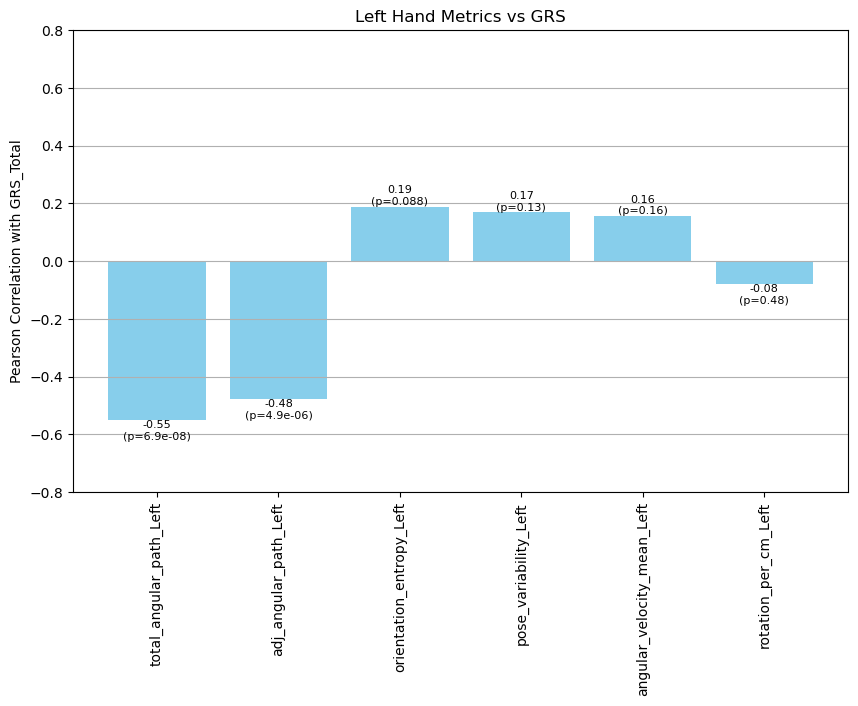

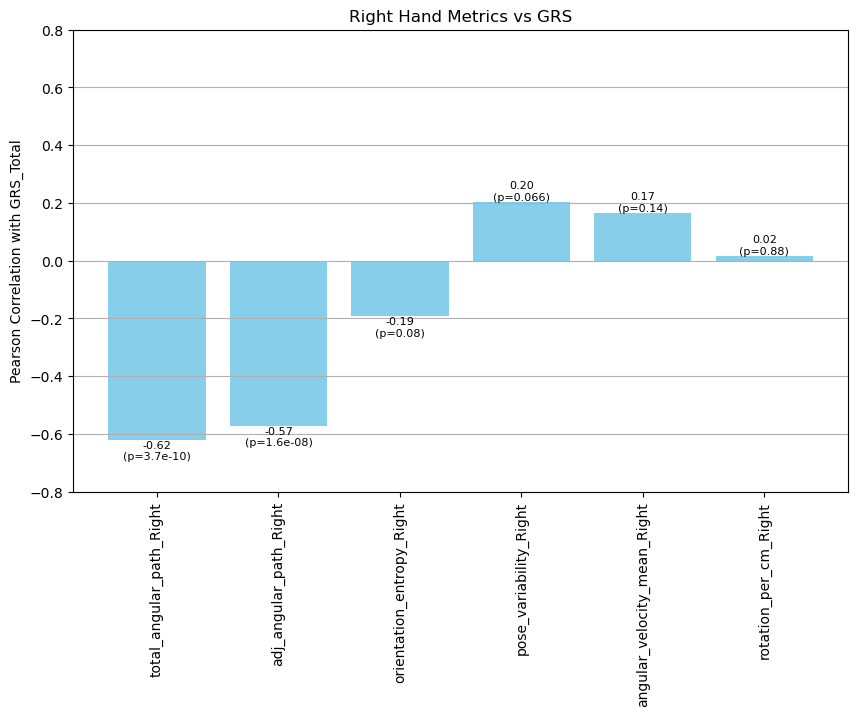

In [36]:
# Left-hand plot
left_metrics = [c for c in df_metrics.columns if c.endswith("_Left")]
left_corr = {k: v for k, v in correlations.items() if k in left_metrics}
plot_metric_correlations(left_corr, title="Left Hand Metrics vs GRS")

# Right-hand plot
right_metrics = [c for c in df_metrics.columns if c.endswith("_Right")]
right_corr = {k: v for k, v in correlations.items() if k in right_metrics}
plot_metric_correlations(right_corr, title="Right Hand Metrics vs GRS")

In [99]:
df_translational_metrics, correlations = analyze_metrics_vs_grs(
    processed_dir="data/processed/landmark_dataframes/",
    ratings_csv="data/scores/merged_scores.csv",
    metric_func=compute_extended_hand_metrics,
    fps=30,
    correlation="spearman",
    end = "30fps_processed.pkl"
)


100%|██████████| 86/86 [00:55<00:00,  1.56it/s]


In [101]:
df = df_translational_metrics.copy()

In [103]:
to_standarize_by_case = ['total_path_Right', 'adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right']

groups = df.groupby('Case_Number')
for name, df_group in tqdm(groups, desc="Standardizing by case"):
    for col in to_standarize_by_case:
        mean = df_group[col].mean()
        std = df_group[col].std()
        if std > 0:
            df.loc[df_group.index, col] = (df_group[col] - mean) / std

Standardizing by case:   0%|          | 0/3 [00:00<?, ?it/s]/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_14752/814607473.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.38061021e-01  1.76474890e+00 -3.01635909e-01  6.13048159e-01
  5.48428925e-03  1.46764349e+00 -6.62168315e-01 -8.12390151e-01
 -1.05942161e+00 -4.61872534e-01 -1.37655660e+00  2.14602623e-03
 -1.06275988e+00 -8.45772781e-01 -6.48815263e-01 -3.21665487e-01
  1.52367862e-01  1.53774702e+00 -8.89170200e-01 -3.55048117e-01
  7.49916943e-01  2.83633133e+00  1.39014810e-01 -2.88282857e-01
  4.55434455e-02 -3.08312435e-01 -9.89318091e-01  1.20725898e+00]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df_group.index, col] = (df_group[col] - mean) / std
/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_14752/814607473.py:9: FutureWarning: Setting an item of incompatib

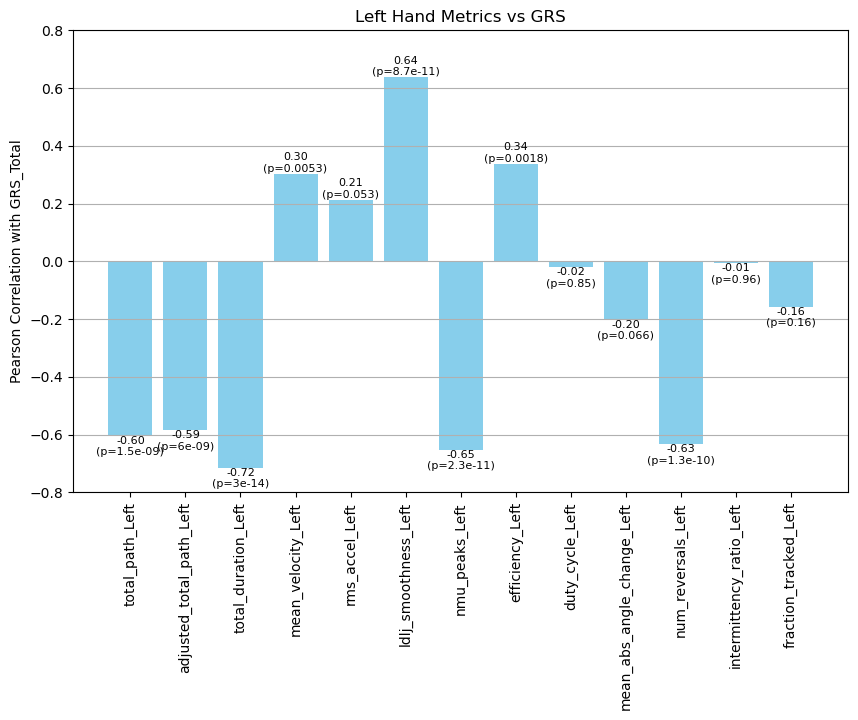

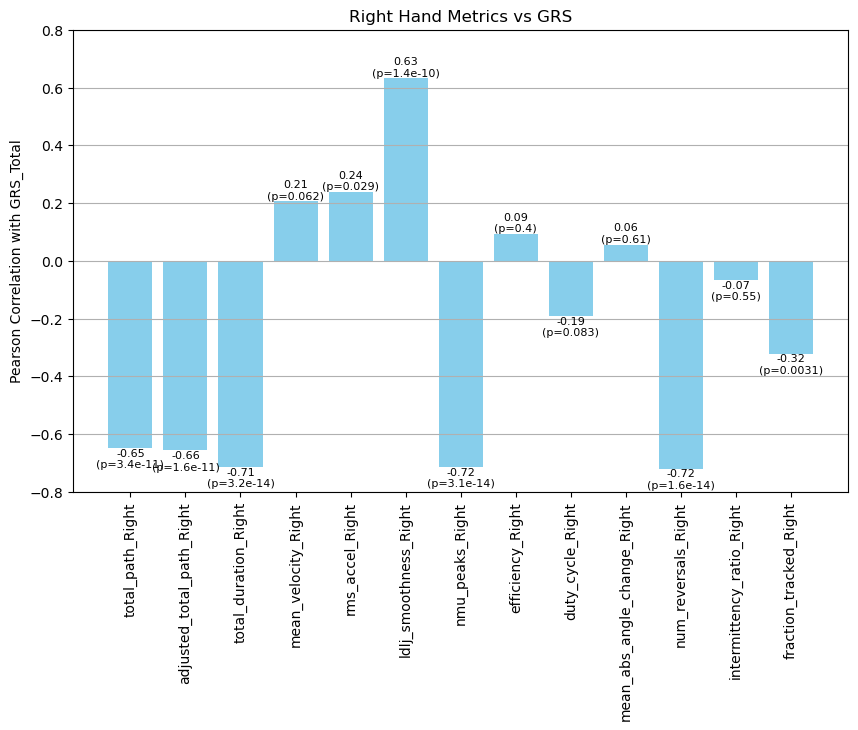

In [116]:
# Left-hand plot
left_metrics = [c for c in df_translational_metrics.columns if c.endswith("_Left")]
left_corr = {k: v for k, v in correlations.items() if k in left_metrics}
plot_metric_correlations(left_corr, title="Left Hand Metrics vs GRS")

# Right-hand plot
right_metrics = [c for c in df_translational_metrics.columns if c.endswith("_Right")]
right_corr = {k: v for k, v in correlations.items() if k in right_metrics}
plot_metric_correlations(right_corr, title="Right Hand Metrics vs GRS")

In [39]:
df_bimanual_metrics, correlations_bimanual = analyze_metrics_vs_grs(
    processed_dir="data/processed/landmark_dataframes/",
    ratings_csv="data/scores/merged_scores.csv",
    metric_func=compute_bimanual_dexterity,
    fps=30,
    correlation="spearman",
    score_col='QRS_Overal',
    end = "30fps_processed.pkl"
)

100%|██████████| 86/86 [00:46<00:00,  1.83it/s]


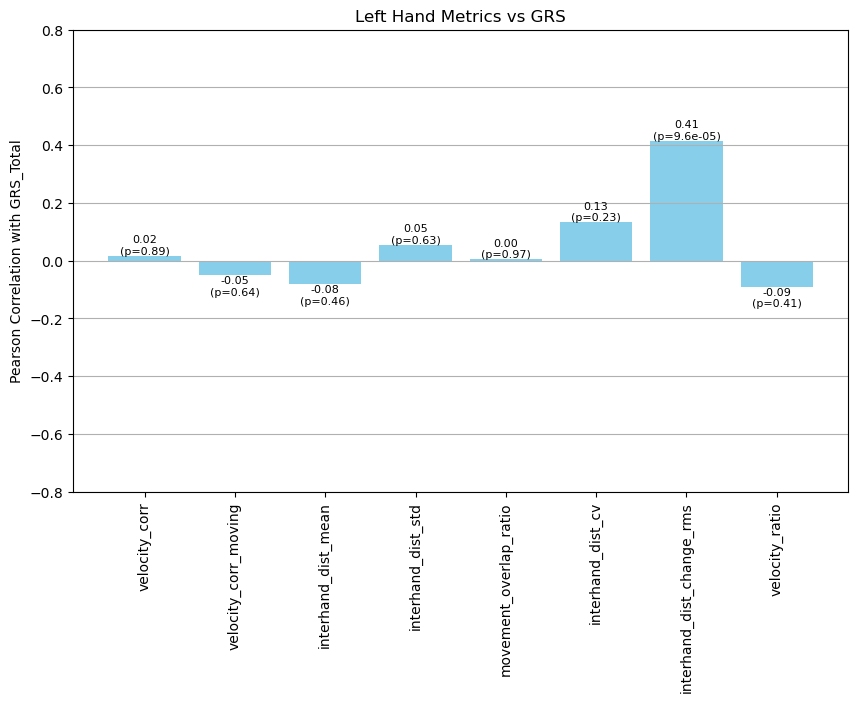

In [40]:
# Left-hand plot
left_metrics = [c for c in df_bimanual_metrics.columns if c.endswith("_Left")]
plot_metric_correlations(correlations_bimanual, title="Left Hand Metrics vs GRS")


In [41]:
# correlation between total_path and total angular path:
from scipy import stats

r, p = stats.spearmanr(df_translational_metrics['total_duration_Right'], df_translational_metrics['ldlj_smoothness_Right'])
print(r, p)

-0.9103732001175434 8.812223747439489e-33


In [183]:
# merge metric dataframes but only columns that end in '_Left' or '_Right' or Overal
df_metrics = df_metrics[[c for c in df_metrics.columns if c.endswith("_Left") or c.endswith("_Right") or c in ['Participant Number', 'GRS_Total', 'QRS_Overal', 'Case_Number']]]
# same for df_translational_metrics
df_trans = df_translational_metrics[[c for c in df_translational_metrics.columns if c.endswith("_Left") or c.endswith("_Right")]]
# same for df_bimanual_metrics
df_bimanual_metrics = df_bimanual_metrics[['velocity_corr',
       'interhand_dist_mean', 'interhand_dist_std',
       'movement_overlap_ratio', 'interhand_dist_cv',
       'interhand_dist_change_rms', 'velocity_ratio']]

df_all_metrics = pd.merge(df_metrics, df_trans, left_index=True, right_index=True)
df_all_metrics = pd.merge(df_all_metrics, df_bimanual_metrics, left_index=True, right_index=True)

In [184]:
# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_all_metrics['Case_Number'], prefix='Case').astype(int)
df_all_metrics = pd.concat([df_all_metrics, df_case_onehot], axis=1)


# RFE for feature selection and performance assessement

In [200]:
feature_cols = [col for col in df_all_metrics.columns if col not in ['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal']]

right_global_features = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right']

exploratory_cols = [col for col in feature_cols if col not in right_global_features]

df_res = leakage_free_correlation_analysis(df_all_metrics, exploratory_cols+right_global_features, target='QRS_Overal', surgeon_col='Participant Number', n=9)
df_res


Analyzing Folds: 100%|██████████| 28/28 [00:00<00:00, 35.74it/s]


,Feature,Mean_Corr_with_Target,Std_Corr_with_Target,Min_Corr_with_Target,Max_Corr_with_Target,Selection_Stability
31,num_reversals_Right,-0.706788,0.011821,-0.738612,-0.689829,1.000000
29,nmu_peaks_Right,-0.702595,0.012162,-0.739957,-0.685475,1.000000
42,total_duration_Left,-0.684729,0.011293,-0.714053,-0.666340,1.000000
43,total_duration_Right,-0.684197,0.011335,-0.713487,-0.665757,1.000000
28,nmu_peaks_Left,-0.663028,0.012668,-0.682062,-0.640420,1.000000
45,total_path_Right,-0.660241,0.014752,-0.698432,-0.641266,1.000000
6,adjusted_total_path_Right,-0.646719,0.014824,-0.692613,-0.626967,1.000000
21,ldlj_smoothness_Left,0.644655,0.016003,0.616883,0.697345,1.000000
22,ldlj_smoothness_Right,0.623674,0.011696,0.599504,0.647350,0.785714
30,num_reversals_Left,-0.613424,0.015770,-0.646121,-0.574218,0.214286


In [210]:
['num_reversals_Right', 'nmu_peaks_Right', 'total_duration_Right', 'nmu_peaks_Left', 'total_duration_Right', 'ldlj_smoothness_Left']

feats = df_res[(df_res['Mean_Corr_with_Target'] > 0.5) | (df_res['Mean_Corr_with_Target'] < -0.5)].Feature

df_all_metrics[feats].corr()

,num_reversals_Right,nmu_peaks_Right,total_duration_Left,total_duration_Right,nmu_peaks_Left,total_path_Right,adjusted_total_path_Right,ldlj_smoothness_Left,ldlj_smoothness_Right,num_reversals_Left,total_angular_path_Right,total_path_Left,adjusted_total_path_Left,total_angular_path_Left,adj_angular_path_Right
num_reversals_Right,1.000000,0.906934,0.821080,0.821834,0.803988,0.962099,0.943497,-0.704824,-0.733885,0.759785,0.830524,0.745549,0.680073,0.688739,0.752809
nmu_peaks_Right,0.906934,1.000000,0.944042,0.944638,0.856153,0.914416,0.886775,-0.804800,-0.823567,0.774397,0.820484,0.783880,0.711950,0.693797,0.738110
total_duration_Left,0.821080,0.944042,1.000000,0.999758,0.890698,0.832089,0.824860,-0.847741,-0.894326,0.812606,0.765979,0.806859,0.734937,0.719485,0.710672
total_duration_Right,0.821834,0.944638,0.999758,1.000000,0.888979,0.832739,0.825096,-0.849952,-0.893719,0.811139,0.767441,0.804044,0.734661,0.718262,0.711838
nmu_peaks_Left,0.803988,0.856153,0.890698,0.888979,1.000000,0.794912,0.798904,-0.764310,-0.805886,0.891044,0.723348,0.869188,0.845356,0.875253,0.685191
total_path_Right,0.962099,0.914416,0.832089,0.832739,0.794912,1.000000,0.975152,-0.687918,-0.712063,0.756764,0.809339,0.759428,0.669695,0.660208,0.721341
adjusted_total_path_Right,0.943497,0.886775,0.824860,0.825096,0.798904,0.975152,1.000000,-0.676156,-0.745916,0.778395,0.824677,0.778872,0.701103,0.667057,0.787589
ldlj_smoothness_Left,-0.704824,-0.804800,-0.847741,-0.849952,-0.764310,-0.687918,-0.676156,1.000000,0.780041,-0.604210,-0.690892,-0.569957,-0.534488,-0.605294,-0.642876
ldlj_smoothness_Right,-0.733885,-0.823567,-0.894326,-0.893719,-0.805886,-0.712063,-0.745916,0.780041,1.000000,-0.751245,-0.782316,-0.748336,-0.676128,-0.660431,-0.777489
num_reversals_Left,0.759785,0.774397,0.812606,0.811139,0.891044,0.756764,0.778395,-0.604210,-0.751245,1.000000,0.690715,0.960438,0.937916,0.851383,0.667901


In [45]:
# store df with top features
df_all_metrics[['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'velocity_corr'] + right_global_features].to_csv("data/metrics/top_global_features.csv", index=False)

In [46]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

# --- 1. Prepare Data ---
X = df_all_metrics[feature_cols].values
y = df_all_metrics['QRS_Overal'].values
surgeon_ids = df_all_metrics['Participant Number'].values 

for i in range(3):
    print("Number of features to select:", i+1)
    unique_surgeons = np.unique(surgeon_ids)
    all_fold_preds = []
    all_fold_true = []
    fold_selected_features = []

    print(f"Starting PCA + RFE LOSOCV...")

    for surgeon_out in tqdm(unique_surgeons, desc="RFE Folds"):
        test_indices = np.where(surgeon_ids == surgeon_out)[0]
        train_indices = np.where(surgeon_ids != surgeon_out)[0]
        
        X_train, X_test = X[train_indices], X[test_indices]
        y_train, y_test = y[train_indices], y[test_indices]

        # 1. Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train) # Scale everything first
        X_test_scaled = scaler.transform(X_test)

        # Convert to DF for easy slicing
        X_tr_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
        X_te_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

        # 2. PCA only on the Macro/Right-Hand metrics
        pca = PCA(n_components=2)
        train_macro_pc = pca.fit_transform(X_tr_df[right_global_features])
        test_macro_pc = pca.transform(X_te_df[right_global_features])

        #scale PCs
        pc_scaler = StandardScaler()
        train_macro_pc = pc_scaler.fit_transform(train_macro_pc)
        test_macro_pc = pc_scaler.transform(test_macro_pc)

        # 3. Combine Efficiency PC with Exploratory features
        X_train_combined = np.hstack([train_macro_pc, X_tr_df[exploratory_cols].values])
        X_test_combined = np.hstack([test_macro_pc, X_te_df[exploratory_cols].values])
        
        # Update feature names for tracking
        current_feature_names = ['PC1', 'PC2', 'PC3'] + exploratory_cols

        # 4. RFE on the hybrid set
        # We ask: Does anything 'local' beat or aid the 'global' efficiency?
        estimator = Ridge(alpha=1.0)
        selector = RFE(estimator, n_features_to_select=i+1, step=1)
        selector = selector.fit(X_train_combined, y_train)
        
        # 5. Final Prediction
        X_train_final = X_train_combined[:, selector.support_]
        X_test_final = X_test_combined[:, selector.support_]
        
        final_model = RidgeCV(alphas=np.logspace(-2, 4, 10))
        final_model.fit(X_train_final, y_train)
        
        y_test_pred = final_model.predict(X_test_final)

        all_fold_preds.extend(y_test_pred)
        all_fold_true.extend(y_test)
        
        # ... store results and track feature names ...
        selected_names = [current_feature_names[i] for i in np.where(selector.support_)[0]]
        fold_selected_features.extend(selected_names)

    # --- 4. Evaluate Performance ---
    final_predictions = np.array(all_fold_preds)
    final_true_scores = np.array(all_fold_true)

    standalone_mae = mean_absolute_error(final_true_scores, final_predictions)
    standalone_corr, _ = spearmanr(final_true_scores, final_predictions)

    print("\n=================================================")
    print("        PCA + RFE RESULTS")
    print("=================================================")
    print(f"Spearman Rho: {standalone_corr:.4f}")
    print(f"Overall MAE:  {standalone_mae:.4f}")

    # Check which PC was most stable
    pc_counts = pd.Series(fold_selected_features).value_counts()
    print("\n--- Most Frequently Selected Principal Components ---")
    print(pc_counts)

    print("=================================================")
    print("=================================================")


Number of features to select: 1
Starting PCA + RFE LOSOCV...


RFE Folds: 100%|██████████| 28/28 [00:02<00:00, 11.32it/s]



        PCA + RFE RESULTS
Spearman Rho: 0.7083
Overall MAE:  5.4266

--- Most Frequently Selected Principal Components ---
PC1                         26
adjusted_total_path_Left     1
rotation_per_cm_Right        1
Name: count, dtype: int64
Number of features to select: 2
Starting PCA + RFE LOSOCV...


RFE Folds: 100%|██████████| 28/28 [00:02<00:00, 11.06it/s]



        PCA + RFE RESULTS
Spearman Rho: 0.6670
Overall MAE:  5.7233

--- Most Frequently Selected Principal Components ---
PC1                           26
fraction_tracked_Right        10
PC3                            8
total_angular_path_Left        3
angular_velocity_mean_Left     2
interhand_dist_change_rms      2
mean_velocity_Right            1
adjusted_total_path_Left       1
PC2                            1
total_duration_Left            1
rotation_per_cm_Right          1
Name: count, dtype: int64
Number of features to select: 3
Starting PCA + RFE LOSOCV...


RFE Folds: 100%|██████████| 28/28 [00:02<00:00, 11.39it/s]


        PCA + RFE RESULTS
Spearman Rho: 0.6588
Overall MAE:  5.7905

--- Most Frequently Selected Principal Components ---
PC1                           26
fraction_tracked_Right        11
PC3                           11
total_path_Left                8
adjusted_total_path_Left       5
rotation_per_cm_Right          5
total_duration_Left            3
total_angular_path_Left        3
interhand_dist_change_rms      3
angular_velocity_mean_Left     2
velocity_corr_moving           2
adj_angular_path_Right         2
mean_velocity_Right            1
pose_variability_Right         1
PC2                            1
Name: count, dtype: int64


In [47]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

# --- 1. Prepare Data ---
X = df_all_metrics[feature_cols].values
y = df_all_metrics['QRS_Overal'].values
surgeon_ids = df_all_metrics['Participant Number'].values 

for i in range(5):
    print("Number of features to select:", i+1)
    unique_surgeons = np.unique(surgeon_ids)
    all_fold_preds = []
    all_fold_true = []
    fold_selected_features = []

    print(f"Starting PCA + seq feature selection LOSOCV...")

    for surgeon_out in tqdm(unique_surgeons, desc="RFE Folds"):
        test_indices = np.where(surgeon_ids == surgeon_out)[0]
        train_indices = np.where(surgeon_ids != surgeon_out)[0]
        
        X_train, X_test = X[train_indices], X[test_indices]
        y_train, y_test = y[train_indices], y[test_indices]

        # 1. Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train) # Scale everything first
        X_test_scaled = scaler.transform(X_test)

        # Convert to DF for easy slicing
        X_tr_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
        X_te_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

        # 2. PCA only on the Macro/Right-Hand metrics
        pca = PCA(n_components=3)
        train_macro_pc = pca.fit_transform(X_tr_df[right_global_features])
        test_macro_pc = pca.transform(X_te_df[right_global_features])

        #scale PCs
        pc_scaler = StandardScaler()
        train_macro_pc = pc_scaler.fit_transform(train_macro_pc)
        test_macro_pc = pc_scaler.transform(test_macro_pc)

        # 3. Combine Efficiency PC with Exploratory features
        X_train_combined = np.hstack([train_macro_pc, X_tr_df[exploratory_cols].values])
        X_test_combined = np.hstack([test_macro_pc, X_te_df[exploratory_cols].values])
        
        # Update feature names for tracking
        current_feature_names = ['PC1', 'PC2', 'PC3'] + exploratory_cols

        # 2. Sequential Feature Selection (Forward)
        # This is much more 'cautious' than RFE.
        # It starts with 0 features and adds them one byx one.
        estimator = Ridge(alpha=1.0)
        sfs = SequentialFeatureSelector(
            estimator, 
            n_features_to_select=i+1, # Force it to be very sparse (e.g., top 3)
            direction='forward',
            cv=5 # Internal CV to ensure the feature actually helps
        )

        sfs.fit(X_train_combined, y_train)
        
        # 5. Final Prediction
        X_train_final = X_train_combined[:, sfs.support_]
        X_test_final = X_test_combined[:, sfs.support_]
        
        final_model = RidgeCV(alphas=np.logspace(-2, 4, 10))
        final_model.fit(X_train_final, y_train)
        
        y_test_pred = final_model.predict(X_test_final)

        all_fold_preds.extend(y_test_pred)
        all_fold_true.extend(y_test)
        
        # ... store results and track feature names ...
        selected_names = [current_feature_names[i] for i in np.where(sfs.support_)[0]]
        fold_selected_features.extend(selected_names)

    # --- 4. Evaluate Performance ---
    final_predictions = np.array(all_fold_preds)
    final_true_scores = np.array(all_fold_true)

    standalone_mae = mean_absolute_error(final_true_scores, final_predictions)
    standalone_corr, _ = spearmanr(final_true_scores, final_predictions)

    print("\n=================================================")
    print("        PCA + feature selection RESULTS")
    print("=================================================")
    print(f"Spearman Rho: {standalone_corr:.4f}")
    print(f"Overall MAE:  {standalone_mae:.4f}")

    # Check which PC was most stable
    pc_counts = pd.Series(fold_selected_features).value_counts()
    print("\n--- Most Frequently Selected Principal Components ---")
    print(pc_counts)

    print("=================================================")
    print("=================================================")

Number of features to select: 1
Starting PCA + seq feature selection LOSOCV...


RFE Folds: 100%|██████████| 28/28 [00:18<00:00,  1.52it/s]



        PCA + feature selection RESULTS
Spearman Rho: 0.7101
Overall MAE:  5.2930

--- Most Frequently Selected Principal Components ---
PC1    28
Name: count, dtype: int64
Number of features to select: 2
Starting PCA + seq feature selection LOSOCV...


RFE Folds: 100%|██████████| 28/28 [00:29<00:00,  1.06s/it]



        PCA + feature selection RESULTS
Spearman Rho: 0.6824
Overall MAE:  5.4934

--- Most Frequently Selected Principal Components ---
PC1                          28
rms_accel_Left               20
orientation_entropy_Right     5
adj_angular_path_Right        1
intermittency_ratio_Right     1
interhand_dist_mean           1
Name: count, dtype: int64
Number of features to select: 3
Starting PCA + seq feature selection LOSOCV...


...


        PCA + feature selection RESULTS
Spearman Rho: 0.6563
Overall MAE:  5.7484

--- Most Frequently Selected Principal Components ---
PC1                            28
rms_accel_Left                 20
interhand_dist_mean            14
orientation_entropy_Right       8
total_path_Right                4
velocity_corr                   4
intermittency_ratio_Right       3
adj_angular_path_Right          2
mean_abs_angle_change_Right     1
Name: count, dtype: int64
Number of features to select: 4
Starting PCA + seq feature selection LOSOCV...


RFE Folds: 100%|██████████| 28/28 [00:56<00:00,  2.02s/it]



        PCA + feature selection RESULTS
Spearman Rho: 0.5952
Overall MAE:  6.2305

--- Most Frequently Selected Principal Components ---
PC1                            28
interhand_dist_mean            22
rms_accel_Left                 21
orientation_entropy_Right      14
velocity_corr                   6
rotation_per_cm_Left            6
total_path_Right                4
intermittency_ratio_Right       3
mean_abs_angle_change_Right     2
adj_angular_path_Right          2
fraction_tracked_Left           1
total_angular_path_Right        1
velocity_corr_moving            1
PC3                             1
Name: count, dtype: int64
Number of features to select: 5
Starting PCA + seq feature selection LOSOCV...


RFE Folds: 100%|██████████| 28/28 [01:08<00:00,  2.45s/it]


        PCA + feature selection RESULTS
Spearman Rho: 0.6004
Overall MAE:  6.1421

--- Most Frequently Selected Principal Components ---
PC1                            28
interhand_dist_mean            24
rms_accel_Left                 21
orientation_entropy_Right      17
rotation_per_cm_Left            9
velocity_corr                   8
total_path_Right                6
PC2                             4
intermittency_ratio_Right       3
total_angular_path_Right        3
mean_abs_angle_change_Right     3
fraction_tracked_Left           2
duty_cycle_Right                2
pose_variability_Right          2
adj_angular_path_Right          2
velocity_corr_moving            2
intermittency_ratio_Left        1
angular_velocity_mean_Right     1
mean_abs_angle_change_Left      1
PC3                             1
Name: count, dtype: int64


# residual analysis:

In [220]:
# leakage free version:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.linear_model import Ridge, RidgeCV

def leakage_free_residual_analysis(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    pcs_to_use=[0],
    pca_features=['total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right']
):
    """
    Evaluates candidate features by identifying their contribution to residuals
    using a Leave-One-Surgeon-Out cross-validation approach.
    """
    unique_surgeons = df[surgeon_col].unique()
    fold_results = []

    for surgeon_out in tqdm(unique_surgeons, desc="Analyzing Folds"):
        # Split Data
        df_train = df[df[surgeon_col] != surgeon_out].dropna(subset=[target] + candidate_features + pca_features).copy()
        
        # 1. Baseline PCA & Model (Fit on Train ONLY)
        scaler = StandardScaler()
        X_train_pca_raw = scaler.fit_transform(df_train[pca_features])
        
        pca = PCA(n_components=max(pcs_to_use) + 1)
        train_pcs = pca.fit_transform(X_train_pca_raw)
        
        # Define baseline columns
        pc_cols = [f'PC{i+1}' for i in range(train_pcs.shape[1])]
        df_train[pc_cols] = train_pcs
        used_pc_cols = [pc_cols[i] for i in pcs_to_use]
        
        # 2. Baseline Model (Train residuals)
        y_train = df_train[target].values
        pc_model = Ridge(alpha=0.5)
        pc_model.fit(df_train[used_pc_cols], y_train)
        
        train_residuals = y_train - pc_model.predict(df_train[used_pc_cols])
        pc_resid_var = np.var(train_residuals)

        # 3. Evaluate Candidate Features on this Fold
        for feat in candidate_features:
            # Partial R2 calculation on train set
            X_full = df_train[used_pc_cols + [feat]]
            full_model = Ridge(alpha=0.5)
            full_model.fit(X_full, y_train)
            
            full_resid_var = np.var(y_train - full_model.predict(X_full))
            partial_r2 = 1 - (full_resid_var / pc_resid_var)
            
            # Correlation with residuals
            r, _ = pearsonr(df_train[feat], train_residuals)
            
            fold_results.append({
                'Fold_Surgeon_Out': surgeon_out,
                'Feature': feat,
                'Partial_R2': partial_r2,
                'Resid_Corr': r
            })

    # ==============================
    # 4. Aggregate Results across all folds
    # ==============================
    results_df = pd.DataFrame(fold_results)
    
    # We want to know:
    # 1. Mean Partial R2
    # 2. Selection Frequency (how often is it in the top 10?)
    summary = results_df.groupby('Feature').agg({
        'Partial_R2': ['mean', 'std'],
        'Resid_Corr': ['mean', 'std']
    }).reset_index()
    
    summary.columns = ['Feature', 'Mean_Partial_R2', 'Std_Partial_R2', 'Mean_Resid_Corr', 'Std_Resid_Corr']

    results_df['Resid_Corr'] = results_df['Resid_Corr'].abs()
    
    # Calculate "Stability": How often was this feature in the top 10 of its fold?
    results_df['Rank'] = results_df.groupby('Fold_Surgeon_Out')['Resid_Corr'].rank(ascending=False)
    stability = results_df[results_df['Rank'] <= 1]['Feature'].value_counts() / len(unique_surgeons)
    stability = stability.rename('Selection_Stability').reset_index().rename(columns={'index': 'Feature'})
    
    final_summary = summary.merge(stability, on='Feature', how='left').fillna(0)
    
    return final_summary.sort_values('Mean_Partial_R2', ascending=False)

# Usage:
#exploratory_cols.remove('velocity_corr_moving')
df_res_leakage_free = leakage_free_residual_analysis(df_all_metrics, exploratory_cols, pca_features=['num_reversals_Right',
 'nmu_peaks_Right',
 'total_duration_Left',
 'nmu_peaks_Left',
 'total_path_Right',
 'ldlj_smoothness_Left'])
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:05<00:00,  4.93it/s]


,Feature,Mean_Partial_R2,Std_Partial_R2,Mean_Resid_Corr,Std_Resid_Corr,Selection_Stability
42,velocity_corr,0.083828,0.014074,-0.304787,0.028995,0.964286
2,Case_3,0.061240,0.008363,0.246958,0.017168,0.035714
30,orientation_entropy_Right,0.044891,0.008835,-0.209603,0.021772,0.000000
0,Case_1,0.029769,0.004838,-0.171380,0.014053,0.000000
43,velocity_ratio,0.025915,0.008689,-0.162360,0.028678,0.000000
33,rms_accel_Left,0.014669,0.005109,-0.113801,0.024665,0.000000
6,angular_velocity_mean_Left,0.010436,0.006970,-0.092669,0.033361,0.000000
16,interhand_dist_mean,0.009679,0.006081,-0.094733,0.026991,0.000000
31,pose_variability_Left,0.008815,0.004412,-0.087336,0.024809,0.000000
12,fraction_tracked_Left,0.008427,0.003300,0.096519,0.022182,0.000000


In [239]:
all_features = [col for col in df_all_metrics.columns if col not in ['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal']]


leakage_free_correlation_analysis(df_all_metrics, all_features)

Analyzing Folds: 100%|██████████| 28/28 [00:00<00:00, 33.24it/s]


,Feature,Mean_Corr_with_Target,Std_Corr_with_Target,Min_Corr_with_Target,Max_Corr_with_Target,Selection_Stability
31,num_reversals_Right,-0.706788,0.011821,-0.738612,-0.689829,1.000000
29,nmu_peaks_Right,-0.702595,0.012162,-0.739957,-0.685475,1.000000
42,total_duration_Left,-0.684729,0.011293,-0.714053,-0.666340,1.000000
43,total_duration_Right,-0.684197,0.011335,-0.713487,-0.665757,1.000000
28,nmu_peaks_Left,-0.663028,0.012668,-0.682062,-0.640420,0.642857
45,total_path_Right,-0.660241,0.014752,-0.698432,-0.641266,0.321429
6,adjusted_total_path_Right,-0.646719,0.014824,-0.692613,-0.626967,0.000000
21,ldlj_smoothness_Left,0.644655,0.016003,0.616883,0.697345,0.035714
22,ldlj_smoothness_Right,0.623674,0.011696,0.599504,0.647350,0.000000
30,num_reversals_Left,-0.613424,0.015770,-0.646121,-0.574218,0.000000


# Fair global model (Top efficiency PC combined with consistently top feature explaining residuals)

2 features = Eff_PC1 + velocity_corr

In [158]:
feats

28          num_reversals_Right
26              nmu_peaks_Right
39          total_duration_Left
40         total_duration_Right
25               nmu_peaks_Left
42             total_path_Right
3     adjusted_total_path_Right
18         ldlj_smoothness_Left
19        ldlj_smoothness_Right
27           num_reversals_Left
38     total_angular_path_Right
Name: Feature, dtype: object

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 179.80it/s]


          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.7180
Overall MAE: 5.1581
Overall Std Dev of Errors: 4.0926

--- Per-Fold Performance Summary ---
           Train_MAE   Test_MAE  Test_Corr
SurgeonID                                 
1           4.846116   7.826685  -0.586903
2           5.047583   3.057725   0.841022
3           4.894327   8.480208   0.983166
4           4.914350   6.457424  -0.513033
5           4.881077   7.432507   0.785085
6           5.093168   1.502942   0.870412
7           4.848482   7.688108  -0.909164
9           5.011296   4.633504  -0.658914
10          5.018335   4.368199   0.703534
11          5.068810   2.268806   0.230735
12          4.994854   5.184806   0.497031
13          5.028419   3.400857   0.685945
14          4.849527  10.248330  -0.462261
15          4.981850   5.913794   0.885182
16          4.768353   9.943617  -0.920326
17          5.001501   3.913930   0.972394
18          4.897004   7.125412  -0.286549
19          

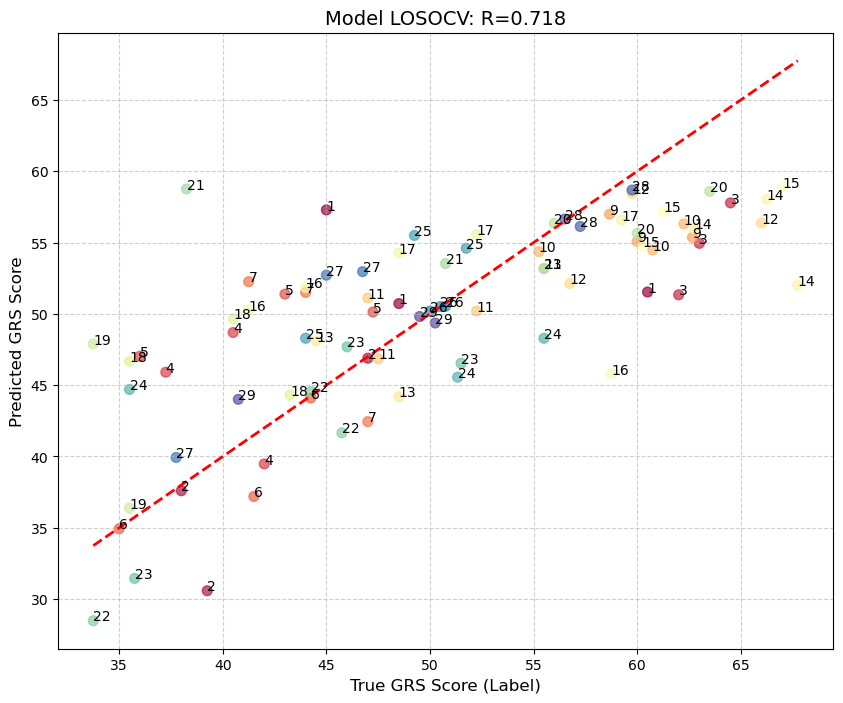

In [238]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and c§orrectly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in ['num_reversals_Right',
 'nmu_peaks_Right',
 'total_duration_Left',
 'nmu_peaks_Left',
 'total_path_Right',
 'ldlj_smoothness_Left']]#['total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right']]#, 'velocity_corr']]
additional_feature_cols = []#['velocity_corr']#, 'Case_3'] #['mean_abs_angle_change_Right']#['Rocket_PC27', 'Rocket_PC7', 'Rocket_PC19', 'Rocket_PC5', 'Rocket_PC24', 'Rocket_PC40']  # 'Rocket_PC25', 'Rocket_PC21', 'Rocket_PC22'
all_feature_cols = feature_cols + additional_feature_cols
X = df_all_metrics[all_feature_cols].values
y = df_all_metrics['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = df_all_metrics['Participant Number'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # PCA but only on feature_cols
    pca = PCA(n_components=min(3, len(feature_cols)))  # Adjust number of components as needed
    X_train_pca = pca.fit_transform(X_train[:, :len(feature_cols)])
    X_test_pca = pca.transform(X_test[:, :len(feature_cols)])
    
    # component list to keep
    component_list = [0]  # Keep only the first principal component
    X_train_pca = X_train_pca[:, component_list]
    X_test_pca = X_test_pca[:, component_list]
    
    # Combine PCA features with additional features
    X_train = np.hstack((X_train_pca, X_train[:, len(feature_cols):]))
    X_test = np.hstack((X_test_pca, X_test[:, len(feature_cols):]))

    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5)                    # RidgeCV(alphas=np.logspace(-2, 4, 20)). TO CHANGE LATER
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

for i, sid in enumerate(surgeon_ids):
    plt.annotate(f'{sid}', (all_fold_true[i], all_fold_preds[i]))

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Model LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [190]:
# check how the features contribute to the PCA components
#feats = right_global_features + ['total_angular_path_Right']
feats = ['num_reversals_Right', 'nmu_peaks_Right', 'total_duration_Right', 'nmu_peaks_Left', 'total_duration_Right', 'ldlj_smoothness_Left']

scaler = StandardScaler()
X = scaler.fit_transform(df_all_metrics[feats].values)

pca = PCA(n_components=len(feats))
pca.fit(X)
components = pca.components_
explained_variance = pca.explained_variance_ratio_

df = pd.DataFrame(components, columns=feats)
df['Explained_Variance'] = explained_variance
df



,num_reversals_Right,nmu_peaks_Right,total_duration_Right,nmu_peaks_Left,total_duration_Right,ldlj_smoothness_Left,Explained_Variance
0,3.900671e-01,4.215588e-01,0.425538,4.015490e-01,0.425538,-3.830526e-01,0.882182
1,6.481312e-01,2.183544e-01,-0.127307,8.097609e-02,-0.127307,7.023361e-01,0.053228
2,-4.780193e-01,-1.505482e-01,0.202521,6.564553e-01,0.202521,4.856644e-01,0.033543
3,2.517133e-01,-3.224315e-01,-0.404917,6.182107e-01,-0.404917,-3.501127e-01,0.024858
4,-3.686619e-01,8.049737e-01,-0.312631,1.381421e-01,-0.312631,-3.931856e-02,0.006188
5,-1.480808e-16,1.928389e-16,0.707107,6.691730e-17,-0.707107,-1.531863e-17,0.000000


# Try PLS

Starting Leave-One-Surgeon-Out CV with PLS (n_components=2)...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 276.10it/s]


          PLS BASELINE LOSOCV RESULTS
Overall Pearson R: 0.6881
Overall MAE: 5.4877


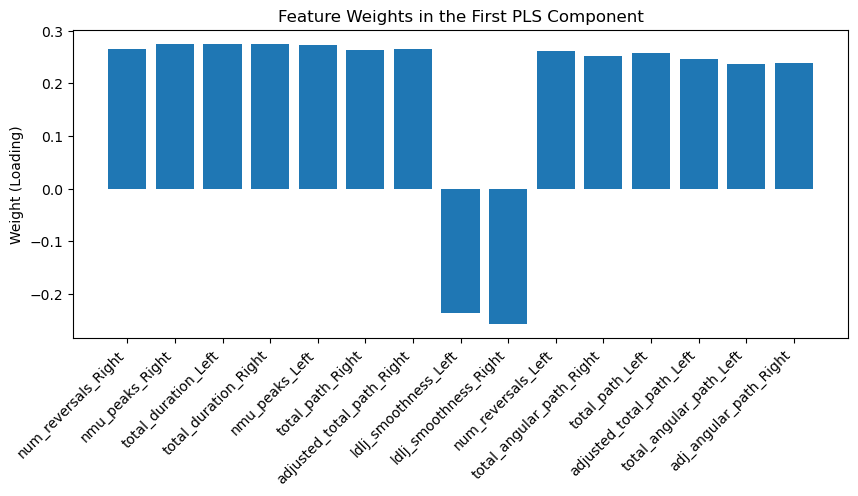

In [216]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data ---
# Use all features you suspect have a signal. 
# PLS will determine the weights (loadings) for each.
all_feature_cols = feats
X = df_all_metrics[all_feature_cols].values
y = df_all_metrics['QRS_Overal'].values
surgeon_ids = df_all_metrics['Participant Number'].values 

unique_surgeons = np.unique(surgeon_ids)
fold_results = {}

all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with PLS (n_components=2)...")

for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # Standardize X and Y (Standard practice for PLS)
    scaler_x = StandardScaler()
    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled = scaler_x.transform(X_test)
    
    # 3. Train PLS Model
    # n_components=2 is a safe starting point for ~80 samples.
    # It will find 2 latent vectors that explain the most covariance.
    model = PLSRegression(n_components=1)
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_test_pred = model.predict(X_test_scaled).flatten() # PLS returns (N, 1)

    # Store results
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate ---
final_predictions = np.array(all_fold_preds)
final_true_scores = np.array(all_fold_true)

overall_mae = mean_absolute_error(final_true_scores, final_predictions)
overall_corr, _ = pearsonr(final_true_scores, final_predictions)

print("\n=================================================")
print("          PLS BASELINE LOSOCV RESULTS")
print("=================================================")
print(f"Overall Pearson R: {overall_corr:.4f}")
print(f"Overall MAE: {overall_mae:.4f}")

# --- 5. Visualizing the "Hidden" Power of PLS ---
# In your thesis, you can plot the "Loadings" to show which features 
# the model actually found important.
# This proves it's not a "black box."
plt.figure(figsize=(10, 4))
loadings = model.x_loadings_[:, 0] # First latent component
plt.bar(all_feature_cols, loadings)
plt.xticks(rotation=45, ha='right')
plt.title("Feature Weights in the First PLS Component")
plt.ylabel("Weight (Loading)")
plt.show()